In [1]:
import scarf
import scarf.plotting as splt

scarf.configure_output(level="WARNING", progress=True)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(
    f"{dataset}/data.zarr",
    nthreads=4,
)

Downloading bucket files: 38209567 / 38209567 complete

Downloading bytes: 38209567 / 38209567 complete

In [2]:
for t in (1, 2, 4):
    ds.cells.insert(
        f"CD4_imputed_t{t}",
        ds.get_imputed(feature_name="CD4", t=t),
        overwrite=True,
    )

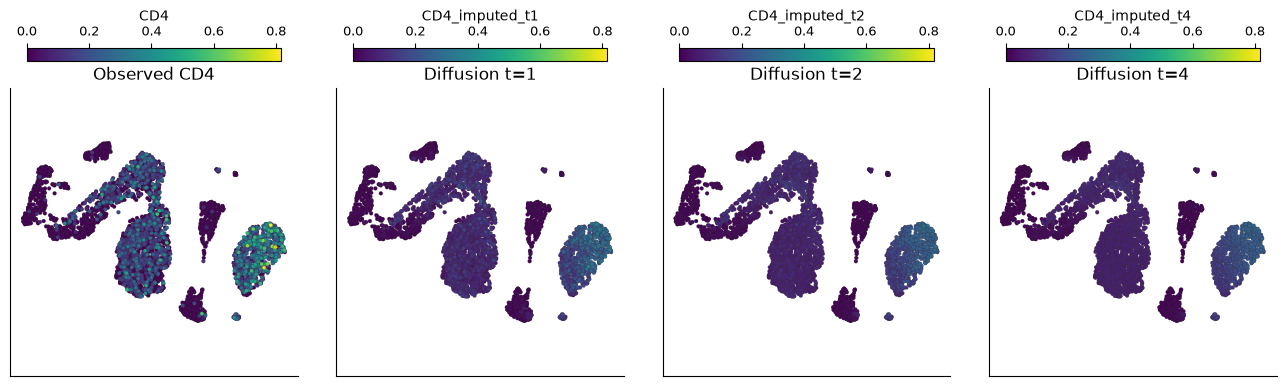

In [3]:
imputation_comparison = ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by=[
        "CD4",
        "CD4_imputed_t1",
        "CD4_imputed_t2",
        "CD4_imputed_t4",
    ],
    n_columns=4,
    color_scale=splt.ColorScale(scope="shared"),
    sort_values=True,
    show_titles=False,
    show=False,
)
for axis, title in zip(
    imputation_comparison.axes.values(),
    ("Observed CD4", "Diffusion t=1", "Diffusion t=2", "Diffusion t=4"),
    strict=True,
):
    axis.set_title(title)